# Correlations

In [91]:
import pickle
import torch
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Read in data

In [50]:
# Infectivity
mutation_file = 'results/mutation_infectivity_effects.csv'
infectivity = pd.read_csv(mutation_file)

In [52]:
# Neutralization
neutralization_file = 'results/mutation_neutralization_effects.csv'
neutralization = pd.read_csv(neutralization_file)

In [64]:
# PyR0
pyro_file = 'data/Pyr0/2023-09-19/mutations.tsv'
pyro = pd.read_csv(pyro_file, sep='\t', usecols=['mutation', 'R / R_A', 'R / R_A 95% ci lower', 'R / R_A 95% ci upper']).rename(columns={'mutation':'Mutation'})
pyro = pyro[pyro['Mutation'].str.startswith('S:')]
pyro['Mutation'] = pyro['Mutation'].apply(lambda x: x[2:])

In [73]:
# BVAS
bvas_file = 'data/BVAS/2023-09-20/allele_summary.csv'
bvas = pd.read_csv(bvas_file).rename(columns={'Unnamed: 0':'Mutation'}).drop(columns='Rank')
bvas = bvas[bvas['Mutation'].str.startswith('S:')]
bvas['Mutation'] = bvas['Mutation'].apply(lambda x: x[2:])

In [93]:
# Join
df = pd.DataFrame()
df = pd.merge(infectivity, neutralization, on='Mutation', suffixes=[' Infectivity', ' Neutralization'])
df = pd.merge(df, pyro, on='Mutation', suffixes=['', ''])
df = pd.merge(df, bvas, on='Mutation', suffixes=['', ''])
df

,Mutation,Mean Infectivity,Std Infectivity,Mean Neutralization,Std Neutralization
0,V213G,0.435199,0.475813,-38.983555,91.414850
1,Q493K,0.423580,0.560377,89.670330,93.242410
2,Q493R,0.306470,0.228590,-143.093460,72.322900
3,Q493S,0.119798,0.383595,93.488360,94.249370
4,R346T,0.081662,0.203540,51.744858,77.165170
5,F490R,0.031927,0.286097,47.244610,88.751460
6,Q183V,0.030946,0.393135,66.940636,96.503240
7,M153S,0.029719,0.361028,-30.878979,87.854866
8,A27L,-0.006387,0.301495,78.405330,88.919395
9,Q498Y,-0.013348,0.365417,73.714010,96.195330


In [96]:
assert False, 'THERE ARE TWO PROBLEMS - NOT ENOUGH MUTATIONS IN THE INTERSECTION OF ALL DFs PLUS NEUTRALIZATOIN RESULTS ARE WRONG'

AssertionError: THERE ARE TWO PROBLEMS - NOT ENOUGH MUTATIONS IN THE INTERSECTION OF ALL DFs PLUS NEUTRALIZATOIN RESULTS ARE WRONG

## Compare

<AxesSubplot: xlabel='Mean Neutralization', ylabel='R / R_A'>

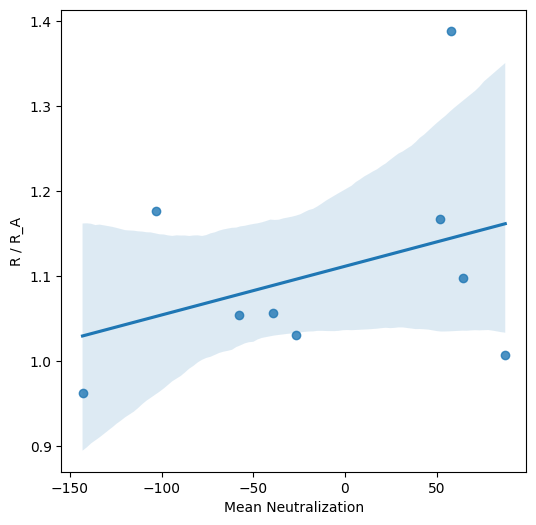

In [92]:
# Neutralization vs PyR0
fig, ax = plt.subplots(figsize=(6,6))
sns.regplot(x='Mean Neutralization',
            y='R / R_A',
            data=df[['Mutation', 'Mean Neutralization', 'R / R_A']],
            ax=ax)

In [86]:
# Infectivity vs PyR0

In [87]:
# Neutralization vs Infectivity

In [88]:
# Neutralization vs BVAS Beta

In [89]:
# Infectivity vs BVAS Beta